In [26]:
# Importamos la librería pandas para manejo de datos en tablas
import pandas as pd

# Cargamos el dataset desde una URL en formato CSV separado por ";"
total_data = pd.read_csv(
    "https://raw.githubusercontent.com/4GeeksAcademy/logistic-regression-project-tutorial/main/bank-marketing-campaign-data.csv",
    sep=";"
)


   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

/tmp/ipykernel_11903/1073781291.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = total_data.select_dtypes(include=['object']).columns


               age      duration      campaign         pdays      previous  \
count  41188.00000  41188.000000  41188.000000  41188.000000  41188.000000   
mean      40.02406    258.285010      2.567593    962.475454      0.172963   
std       10.42125    259.279249      2.770014    186.910907      0.494901   
min       17.00000      0.000000      1.000000      0.000000      0.000000   
25%       32.00000    102.000000      1.000000    999.000000      0.000000   
50%       38.00000    180.000000      2.000000    999.000000      0.000000   
75%       47.00000    319.000000      3.000000    999.000000      0.000000   
max       98.00000   4918.000000     56.000000    999.000000      7.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx     euribor3m   nr.employed  
count  41188.000000    41188.000000   41188.000000  41188.000000  41188.000000  
mean       0.081886       93.575664     -40.502600      3.621291   5167.035911  
std        1.570960        0.578840       4.628198    

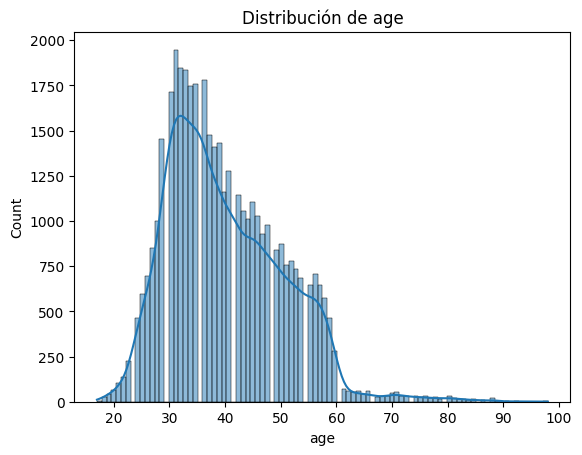

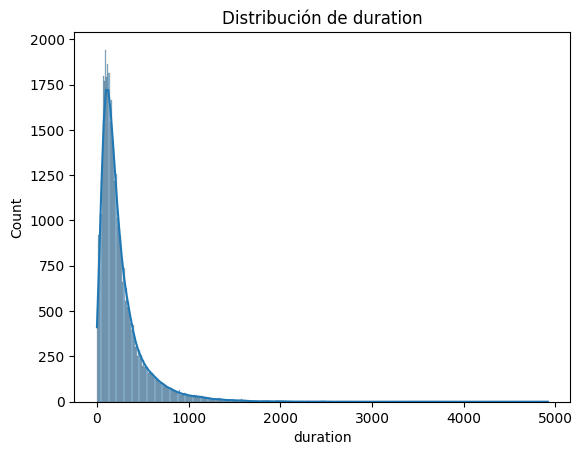

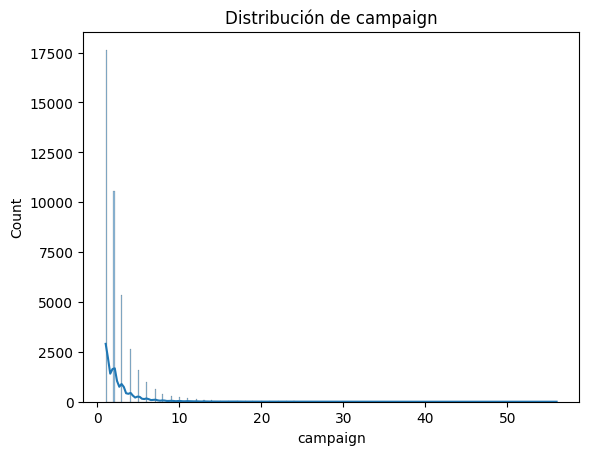

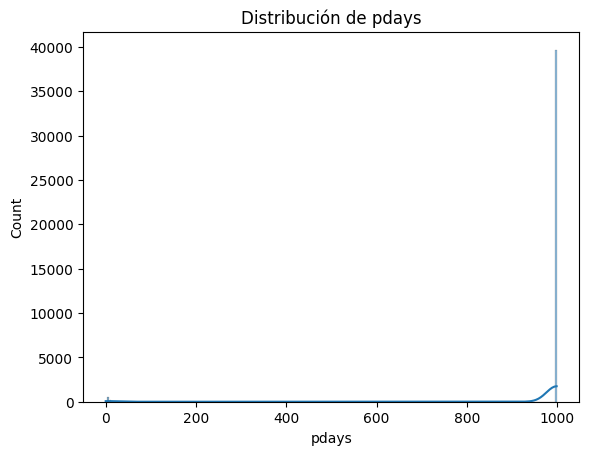

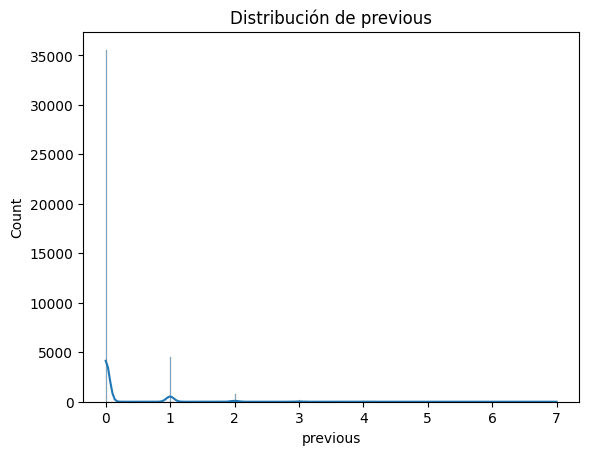

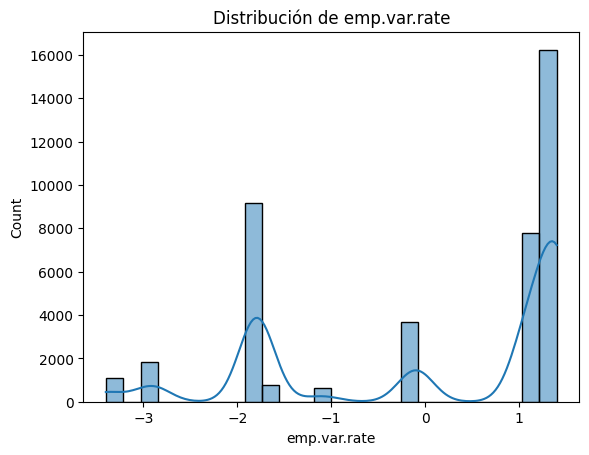

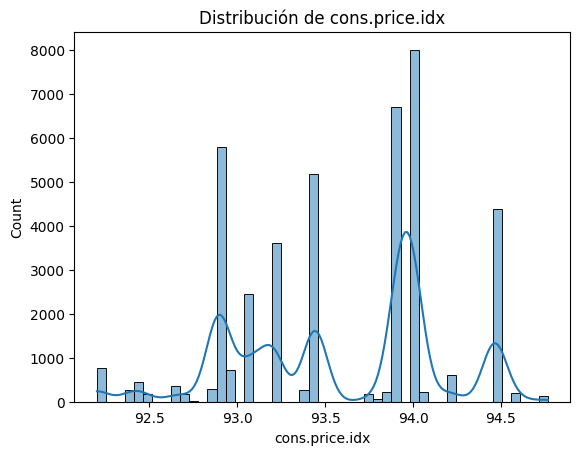

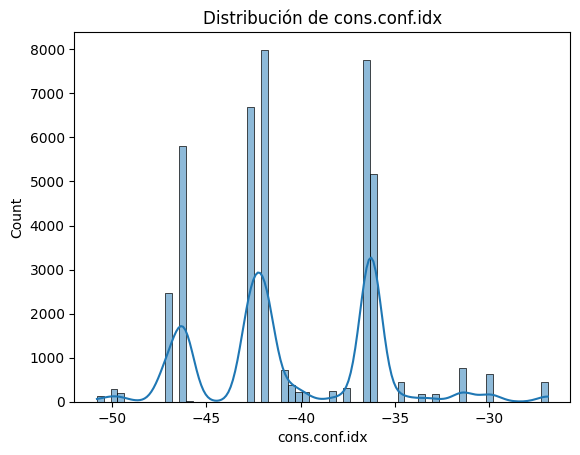

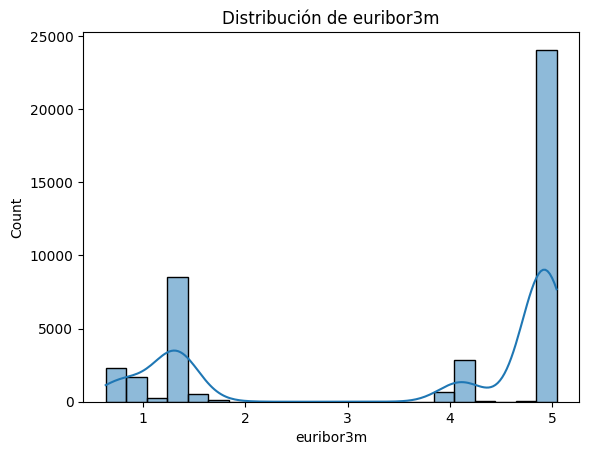

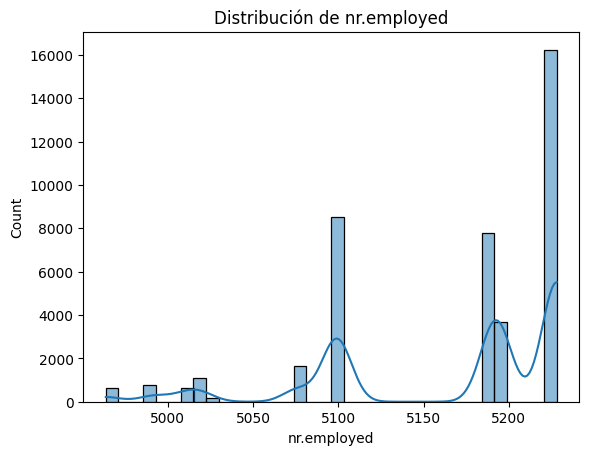

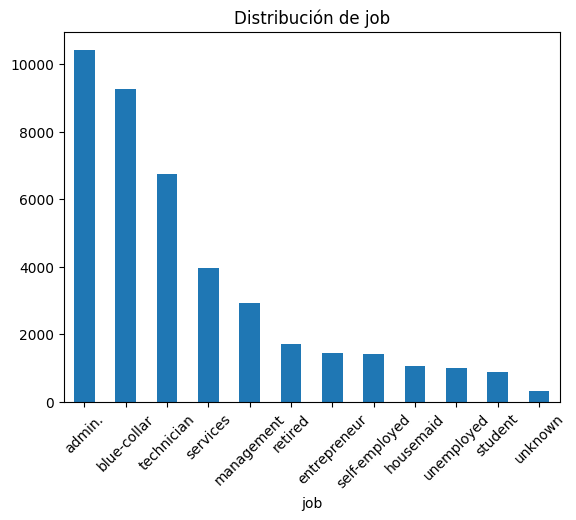

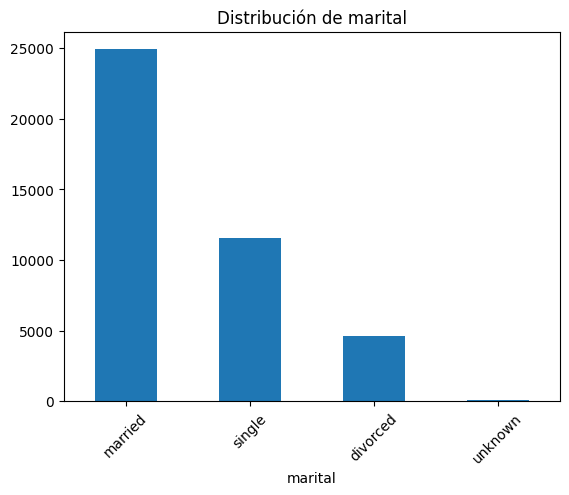

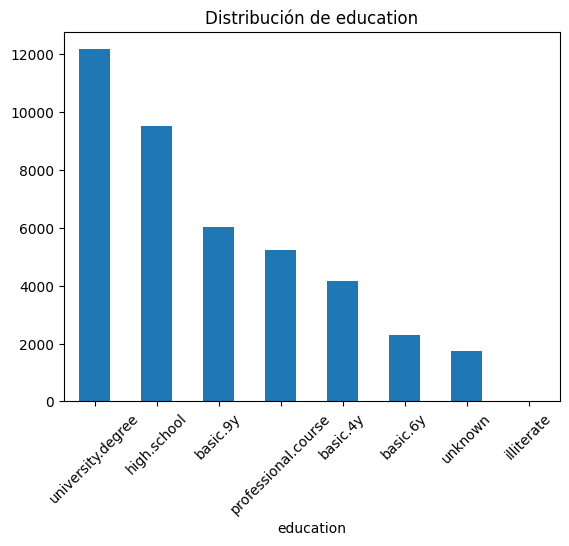

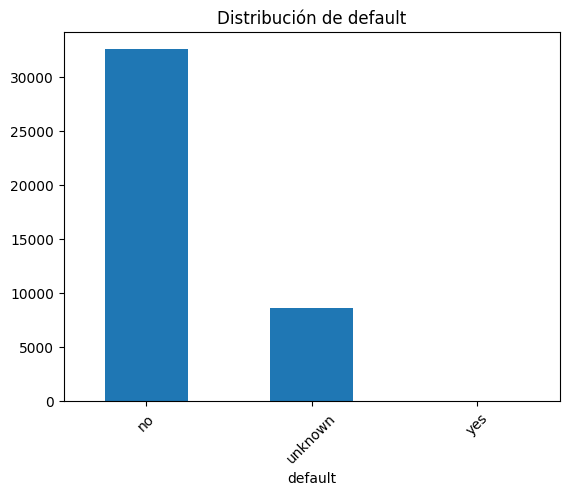

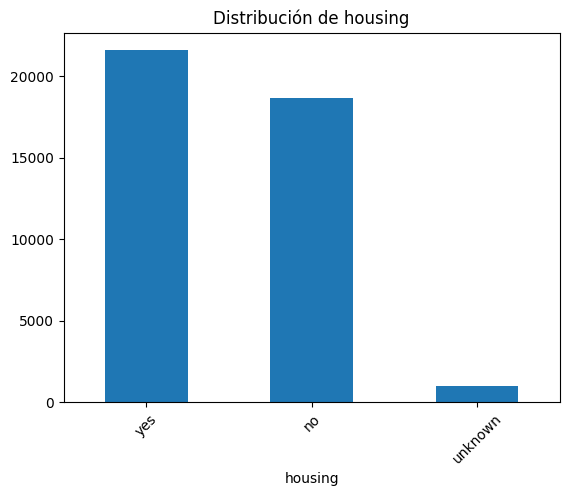

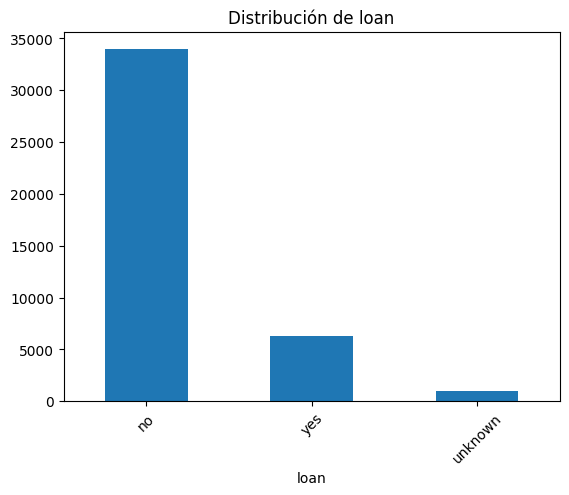

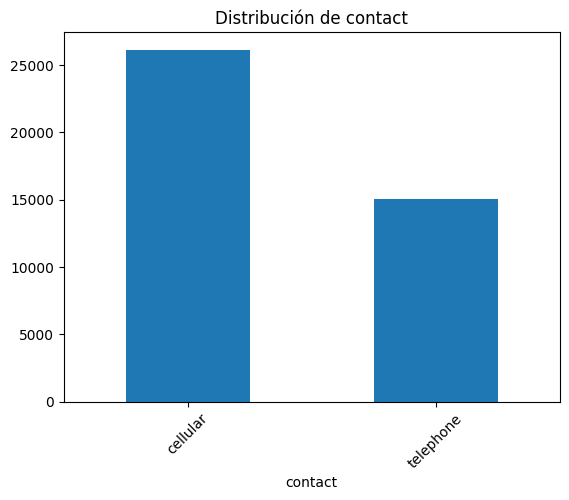

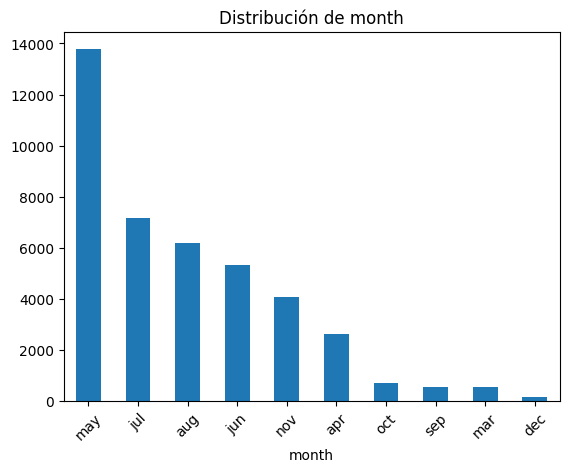

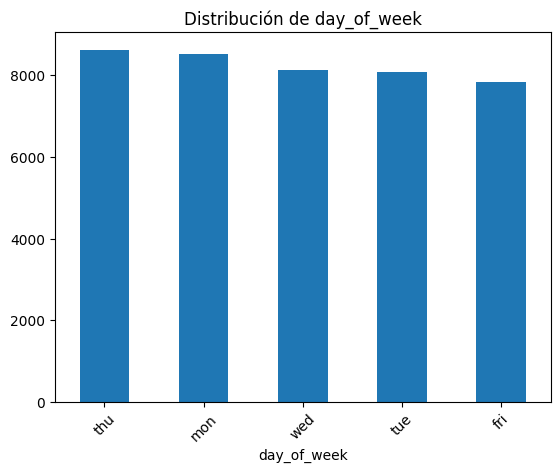

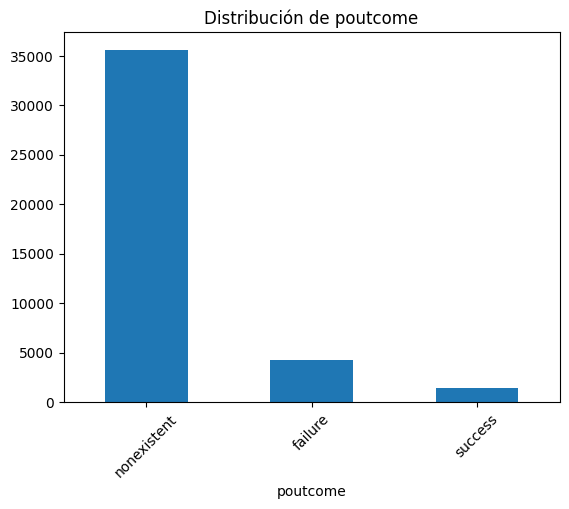

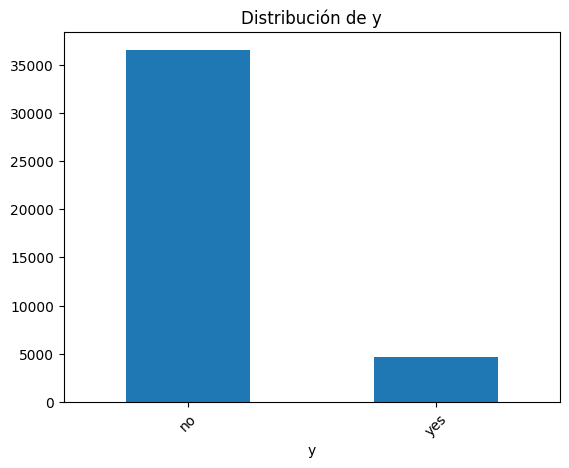

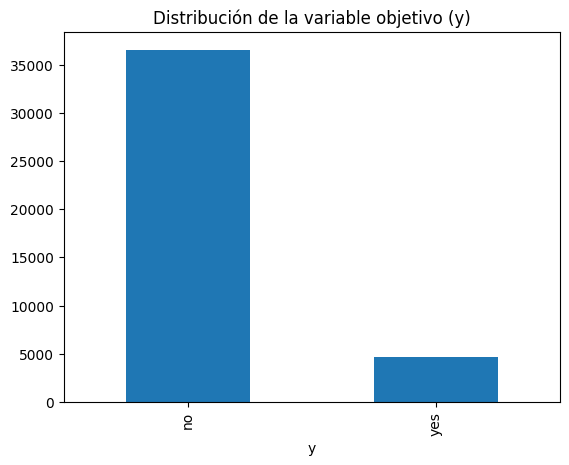

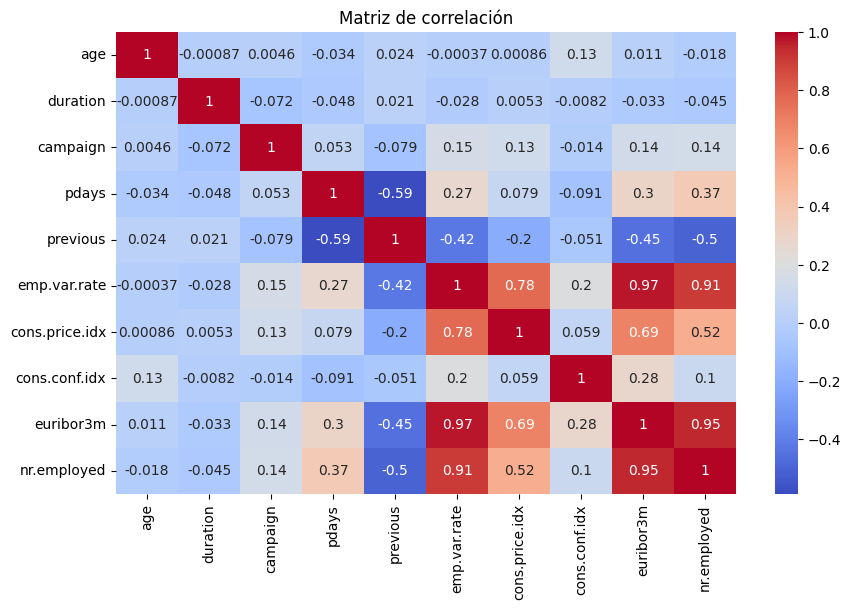

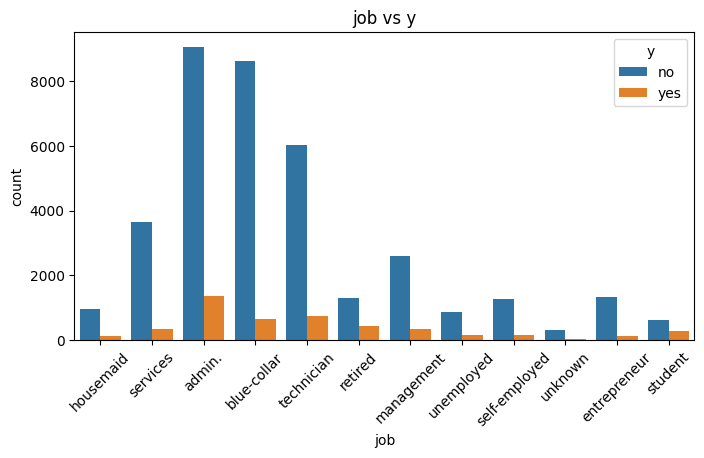

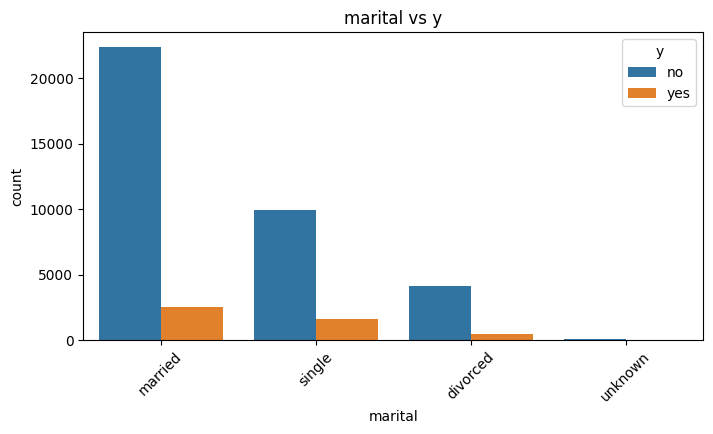

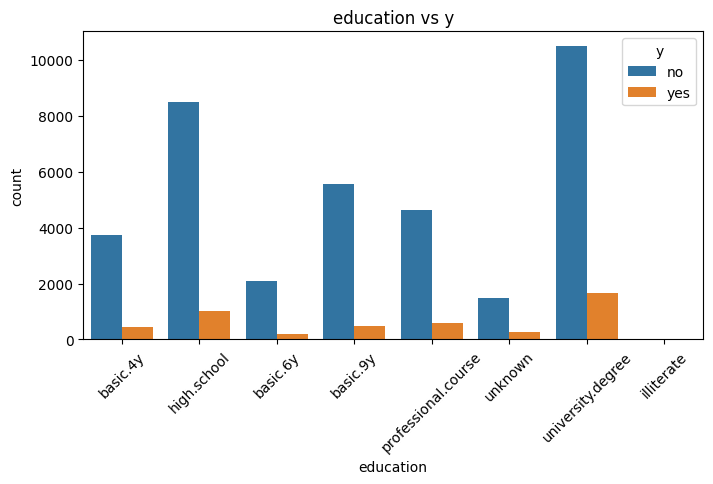

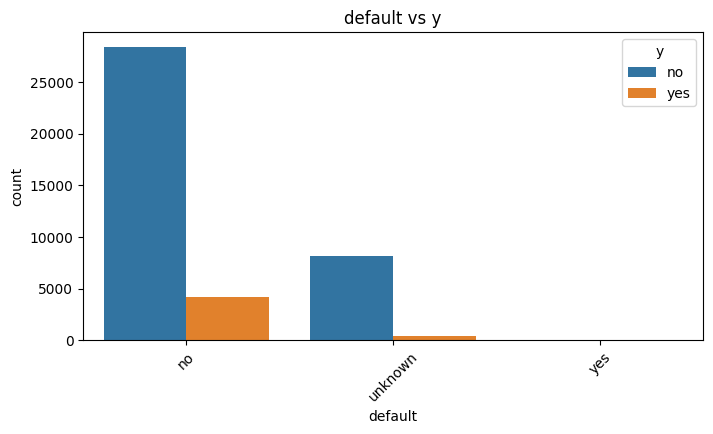

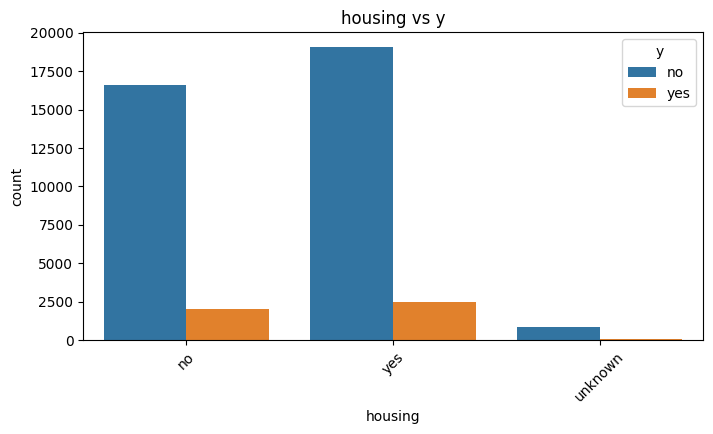

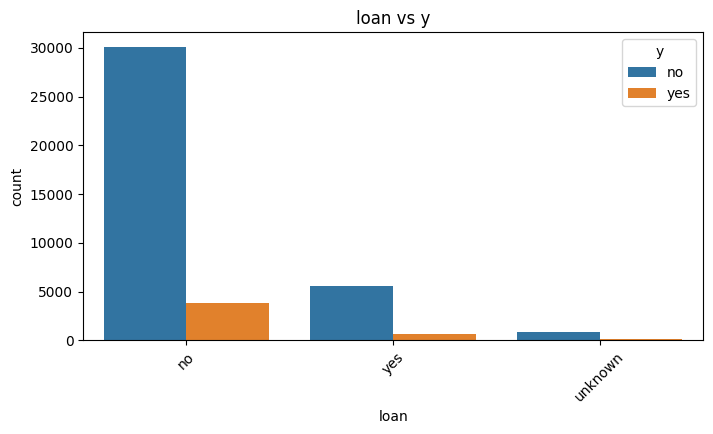

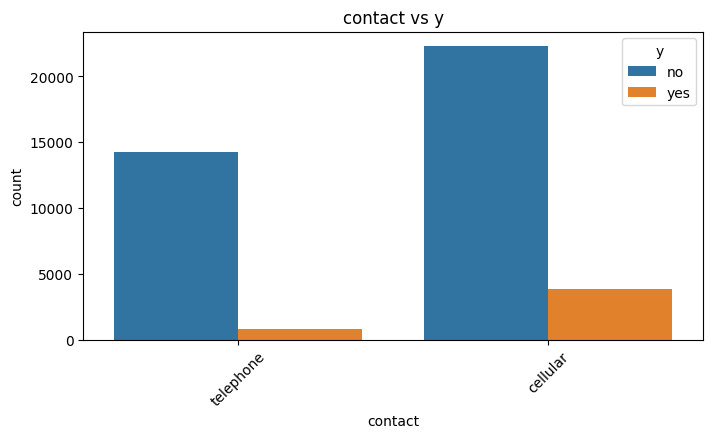

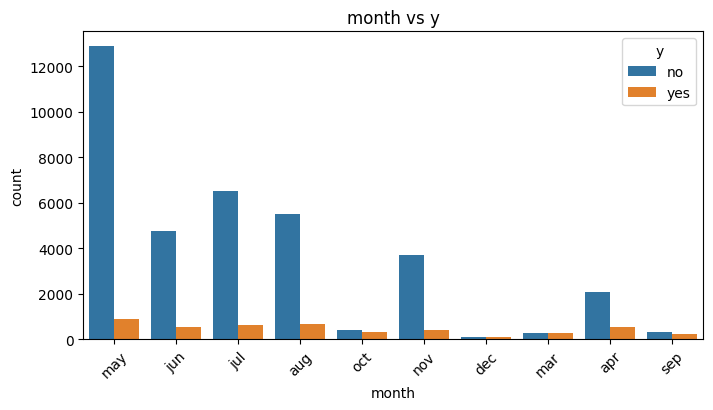

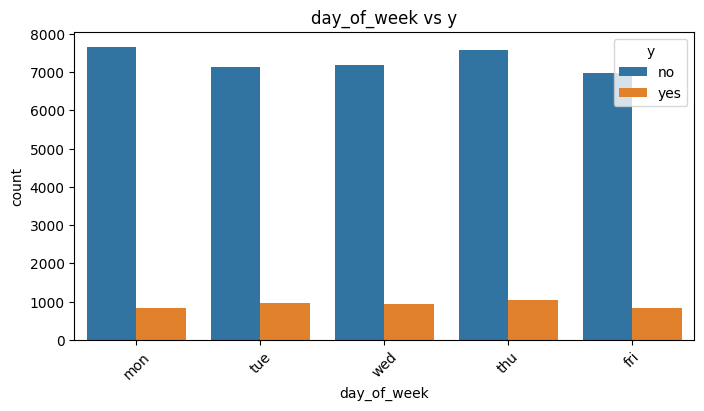

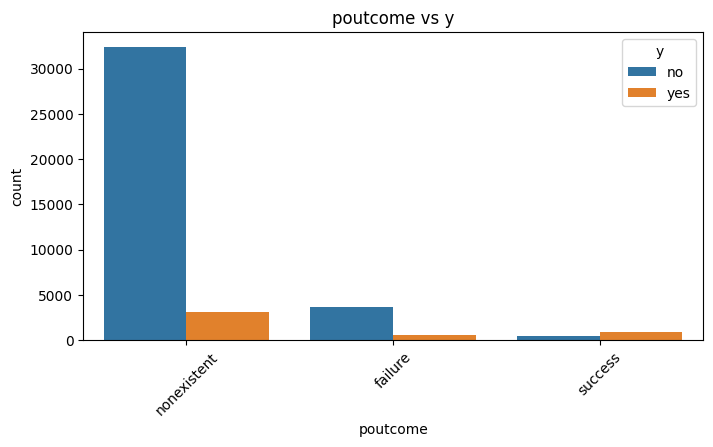

'\n- El dataset combina variables numéricas y categóricas.\n- No hay muchos nulos, pero existen valores "unknown".\n- La variable objetivo suele estar desbalanceada.\n- Algunas variables categóricas parecen influir bastante en la respuesta.\n- Las correlaciones entre variables numéricas no son muy fuertes.\n\nEste análisis sirve como base para el preprocesamiento y posterior modelado.\n'

In [8]:
#EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
url = "https://raw.githubusercontent.com/4GeeksAcademy/logistic-regression-project-tutorial/main/bank-marketing-campaign-data.csv"
total_data = pd.read_csv(url, sep=";")

# -------------------------------
# 1. Primer vistazo al dataset
# -------------------------------

# Ver las primeras filas
print(total_data.head())

# Dimensiones del dataset
print(f"El dataset tiene {total_data.shape[0]} filas y {total_data.shape[1]} columnas")

# Información general
print(total_data.info())

# -------------------------------
# 2. Tipos de variables
# -------------------------------

# Separar variables numéricas y categóricas
num_cols = total_data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = total_data.select_dtypes(include=['object']).columns

print("Variables numéricas:", num_cols)
print("Variables categóricas:", cat_cols)

# -------------------------------
# 3. Valores nulos
# -------------------------------

# Comprobar si hay valores nulos
nulls = total_data.isnull().sum()
print("Valores nulos por columna:\n", nulls)

# Comentario:
# En este dataset no suelen aparecer valores nulos explícitos, 
# pero sí puede haber valores como "unknown" que actúan como tal.

# -------------------------------
# 4. Estadística descriptiva
# -------------------------------

# Variables numéricas
print(total_data[num_cols].describe())

# Variables categóricas
for col in cat_cols:
    print(f"\nFrecuencias de {col}:")
    print(total_data[col].value_counts())

# -------------------------------
# 5. Análisis univariante
# -------------------------------

# Distribución de variables numéricas
for col in num_cols:
    plt.figure()
    sns.histplot(total_data[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

# Distribución de variables categóricas
for col in cat_cols:
    plt.figure()
    total_data[col].value_counts().plot(kind='bar')
    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45)
    plt.show()

# -------------------------------
# 6. Variable objetivo
# -------------------------------

# Ver distribución del target (y)
plt.figure()
total_data['y'].value_counts().plot(kind='bar')
plt.title("Distribución de la variable objetivo (y)")
plt.show()

# Comentario:
# Es importante comprobar si hay desbalanceo de clases,
# ya que puede afectar al rendimiento del modelo.

# -------------------------------
# 7. Correlaciones
# -------------------------------

# Matriz de correlación
plt.figure(figsize=(10, 6))
sns.heatmap(total_data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

# Comentario:
# Esto permite ver relaciones entre variables numéricas,
# aunque en este dataset suelen ser bastante bajas.

# -------------------------------
# 8. Relación con la variable objetivo
# -------------------------------

# Ejemplo con variables categóricas
for col in cat_cols:
    if col != 'y':
        plt.figure(figsize=(8,4))
        sns.countplot(data=total_data, x=col, hue='y')
        plt.title(f"{col} vs y")
        plt.xticks(rotation=45)
        plt.show()

# Comentario:
# Aquí analizamos cómo influyen las variables en la respuesta del cliente.

# -------------------------------
# 9. Conclusiones rápidas
# -------------------------------

"""
- El dataset combina variables numéricas y categóricas.
- No hay muchos nulos, pero existen valores "unknown".
- La variable objetivo suele estar desbalanceada.
- Algunas variables categóricas parecen influir bastante en la respuesta.
- Las correlaciones entre variables numéricas no son muy fuertes.

Este análisis sirve como base para el preprocesamiento y posterior modelado.
"""

In [ ]:
# Mostramos las primeras filas para inspeccionar la estructura del dataset
total_data.head()

# Eliminamos filas duplicadas y reiniciamos el índice para evitar saltos
total_data = total_data.drop_duplicates().reset_index(drop=True)

# Volvemos a visualizar los datos tras limpieza
total_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [28]:
# Comprobamos valores nulos en cada columna
total_data.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [29]:
# Importamos MinMaxScaler para normalizar variables numéricas
from sklearn.preprocessing import MinMaxScaler

# Convertimos variables categóricas en numéricas usando factorize
total_data["job_n"] = pd.factorize(total_data["job"])[0]
total_data["marital_n"] = pd.factorize(total_data["marital"])[0]
total_data["education_n"] = pd.factorize(total_data["education"])[0]
total_data["default_n"] = pd.factorize(total_data["default"])[0]
total_data["housing_n"] = pd.factorize(total_data["housing"])[0]
total_data["loan_n"] = pd.factorize(total_data["loan"])[0]
total_data["contact_n"] = pd.factorize(total_data["contact"])[0]
total_data["month_n"] = pd.factorize(total_data["month"])[0]
total_data["day_of_week_n"] = pd.factorize(total_data["day_of_week"])[0]
total_data["poutcome_n"] = pd.factorize(total_data["poutcome"])[0]
total_data["y_n"] = pd.factorize(total_data["y"])[0]

# Lista de variables que vamos a usar para el modelo
num_variables = [
    "job_n", "marital_n", "education_n", "default_n", "housing_n", "loan_n",
    "contact_n", "month_n", "day_of_week_n", "poutcome_n",
    "age", "duration", "campaign", "pdays", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m",
    "nr.employed", "y_n"
]

# Creamos el scaler para normalizar datos entre 0 y 1
scaler = MinMaxScaler()

# Aplicamos el escalado a las variables seleccionadas
scal_features = scaler.fit_transform(total_data[num_variables])

# Convertimos el resultado en DataFrame manteniendo nombres de columnas
total_data_scal = pd.DataFrame(
    scal_features,
    index=total_data.index,
    columns=num_variables
)

# Mostramos datos escalados
total_data_scal.head()

,job_n,marital_n,education_n,default_n,housing_n,loan_n,contact_n,month_n,day_of_week_n,poutcome_n,...,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y_n
0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.053070,0.0,1.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,0.0
1,0.090909,0.0,0.142857,0.5,0.0,0.0,0.0,0.0,0.0,0.0,...,0.030297,0.0,1.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,0.0
2,0.090909,0.0,0.142857,0.0,0.5,0.0,0.0,0.0,0.0,0.0,...,0.045954,0.0,1.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,0.0
3,0.181818,0.0,0.285714,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.030704,0.0,1.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,0.0
4,0.090909,0.0,0.142857,0.0,0.0,0.5,0.0,0.0,0.0,0.0,...,0.062424,0.0,1.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,0.0


In [30]:
# Importamos herramientas para selección de variables y división del dataset
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.model_selection import train_test_split

# Separamos variables predictoras (X) y variable objetivo (y)
X = total_data_scal.drop("y_n", axis=1)
y = total_data_scal["y_n"]

# Dividimos en conjunto de entrenamiento y test (90% - 10%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

# Seleccionamos las 5 mejores variables con chi2
selection_model = SelectKBest(chi2, k=5)
selection_model.fit(X_train, y_train)

# Obtenemos máscara de columnas seleccionadas
ix = selection_model.get_support()

# Transformamos dataset de entrenamiento con variables seleccionadas
X_train_sel = pd.DataFrame(
    selection_model.transform(X_train),
    columns=X_train.columns.values[ix]
)

# Transformamos dataset de test con las mismas variables
X_test_sel = pd.DataFrame(
    selection_model.transform(X_test),
    columns=X_test.columns.values[ix]
)

# Mostramos datos de entrenamiento seleccionados
X_train_sel.head()

,poutcome_n,previous,emp.var.rate,euribor3m,nr.employed
0,0.0,0.0,1.000000,0.980730,1.000000
1,0.0,0.0,0.333333,0.138291,0.512287
2,0.0,0.0,0.937500,0.956926,0.859735
3,0.0,0.0,0.937500,0.957379,0.859735
4,0.0,0.0,0.333333,0.175924,0.512287


In [31]:
# Mostramos datos de test seleccionados
X_test_sel.head()

,poutcome_n,previous,emp.var.rate,euribor3m,nr.employed
0,0.0,0.000000,0.104167,0.143278,0.425709
1,0.5,0.142857,0.333333,0.150759,0.512287
2,0.0,0.000000,0.479167,0.073679,0.000000
3,0.5,0.142857,0.333333,0.150759,0.512287
4,0.0,0.000000,1.000000,0.981410,1.000000


In [33]:
# Importamos os para manejar carpetas
import os

# Creamos carpeta donde guardaremos datos procesados
os.makedirs("../data/processed", exist_ok=True)



In [34]:
# Añadimos la variable objetivo a los datasets finales
X_train_sel["y_n"] = list(y_train)
X_test_sel["y_n"] = list(y_test)

# Guardamos datasets procesados en CSV
X_train_sel.to_csv("../data/processed/clean_train.csv", index=False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index=False)

In [35]:
# Cargamos nuevamente los datos procesados
train_data = pd.read_csv("../data/processed/clean_train.csv")
test_data = pd.read_csv("../data/processed/clean_test.csv")

# Visualizamos datos de entrenamiento
train_data.head()

,poutcome_n,previous,emp.var.rate,euribor3m,nr.employed,y_n
0,0.0,0.0,1.000000,0.980730,1.000000,0.0
1,0.0,0.0,0.333333,0.138291,0.512287,0.0
2,0.0,0.0,0.937500,0.956926,0.859735,0.0
3,0.0,0.0,0.937500,0.957379,0.859735,0.0
4,0.0,0.0,0.333333,0.175924,0.512287,0.0


In [36]:
# Separamos variables predictoras y objetivo en train
X_train = train_data.drop(["y_n"], axis=1)
y_train = train_data["y_n"]

# Separamos variables predictoras y objetivo en test
X_test = test_data.drop(["y_n"], axis=1)
y_test = test_data["y_n"]


In [37]:
# Importamos modelo de regresión logística
from sklearn.linear_model import LogisticRegression

# Creamos el modelo con parámetros por defecto
model = LogisticRegression()

# Entrenamos el modelo
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [38]:
# Hacemos predicciones sobre el conjunto de test
y_pred = model.predict(X_test)

# Mostramos predicciones
y_pred

array([0., 0., 0., ..., 0., 0., 0.], shape=(4118,))

In [39]:
# Importamos métrica de accuracy
from sklearn.metrics import accuracy_score

# Evaluamos el modelo
accuracy_score(y_test, y_pred)

0.8919378338999514

In [46]:
# Importamos GridSearch para optimización de hiperparámetros
from sklearn.model_selection import GridSearchCV

# Definimos combinación de hiperparámetros a probar
hyperparams = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]
}

# Creamos GridSearch con validación cruzada de 10 folds
grid = GridSearchCV(model, hyperparams, scoring="accuracy", cv=10)


In [42]:
# Desactivamos warnings para limpieza de salida
def warn(*args, **kwargs):
    pass

import warnings
warnings.warn = warn

# Entrenamos búsqueda de hiperparámetros
grid.fit(X_train, y_train)

# Mostramos mejores parámetros encontrados
print(f"Best hyperparameters: {grid.best_params_}")


Best hyperparameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [43]:
# Creamos modelo final con mejores parámetros
model = LogisticRegression(C=0.1, penalty="l2", solver="liblinear")

# Entrenamos modelo final
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [44]:
# Hacemos predicciones finales
y_pred = model.predict(X_test)

In [ ]:
# Evaluamos modelo final
accuracy_score(y_test, y_pred)


In [47]:
import os  # Importamos módulo para manejar archivos y carpetas

os.makedirs("../models", exist_ok=True)  # Creamos la carpeta models si no existe

from pickle import dump  # Importamos función para guardar el modelo

dump(model, open("../models/logistic_regression_C-0.1_penalty-l2_solver-liblinear_42.sav", "wb"))  # Guardamos el modelo en un archivo .sav

TESTEO 

In [48]:
print("Reales:", y_test.values[:20])
print("Predicciones:", y_pred[:20])

Reales: [1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Predicciones: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [49]:
aciertos = (y_test == y_pred).sum()
print("Aciertos:", aciertos)

Aciertos: 3681


In [50]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8938805245264692


In [51]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[3628   17]
 [ 420   53]]


In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.90      1.00      0.94      3645
         1.0       0.76      0.11      0.20       473

    accuracy                           0.89      4118
   macro avg       0.83      0.55      0.57      4118
weighted avg       0.88      0.89      0.86      4118



“Aunque el modelo presenta una accuracy elevada, el bajo recall de la clase positiva indica que no es capaz de identificar correctamente a los clientes que contratarán el producto, por lo que sería necesario ajustar el modelo o aplicar técnicas de balanceo de clases.”